In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
transaction_path = "../data/raw/train_transaction.csv"
identity_path = "../data/raw/train_identity.csv"

df_transaction = pd.read_csv(transaction_path)
df_identity = pd.read_csv(identity_path)

print("Transaction shape:", df_transaction.shape)
print("Identity shape:", df_identity.shape)

Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [3]:
df_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df = df_transaction.merge(df_identity, on="TransactionID", how="left")

print("Merged dataset shape:", df.shape)


Merged dataset shape: (590540, 434)


In [5]:
df = df.sample(50000, random_state=42)

print("Sampled dataset:", df.shape)

Sampled dataset: (50000, 434)


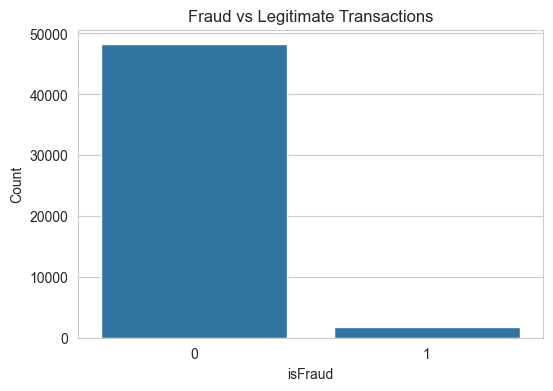

In [6]:
fraud_counts = df['isFraud'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("isFraud")
plt.ylabel("Count")

plt.show()

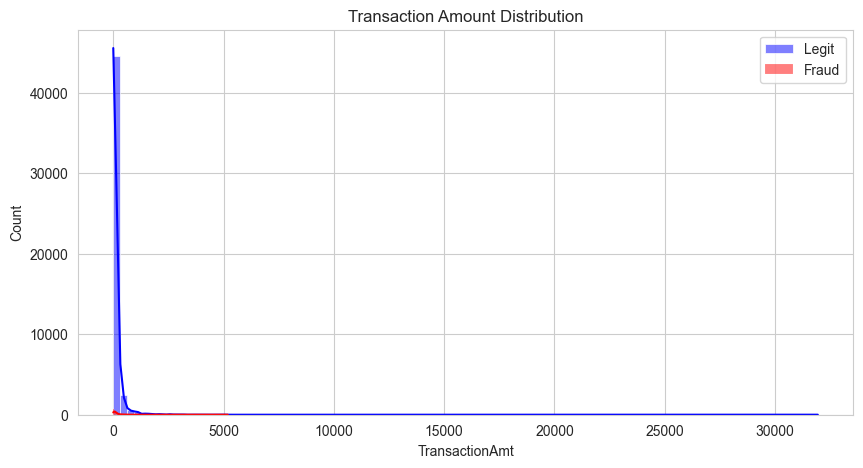

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(df[df['isFraud']==0]['TransactionAmt'], bins=100, color="blue", label="Legit", kde=True)
sns.histplot(df[df['isFraud']==1]['TransactionAmt'], bins=100, color="red", label="Fraud", kde=True)

plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()

In [8]:
missing = df.isnull().mean().sort_values(ascending=False)

missing.head(20)

id_24    0.99262
id_25    0.99196
id_07    0.99194
id_08    0.99194
id_21    0.99192
id_23    0.99190
id_27    0.99190
id_26    0.99190
id_22    0.99190
dist2    0.93730
D7       0.93350
id_18    0.92286
D13      0.89530
D14      0.89480
D12      0.88990
id_04    0.88822
id_03    0.88822
D6       0.87576
id_33    0.87560
id_09    0.87276
dtype: float64

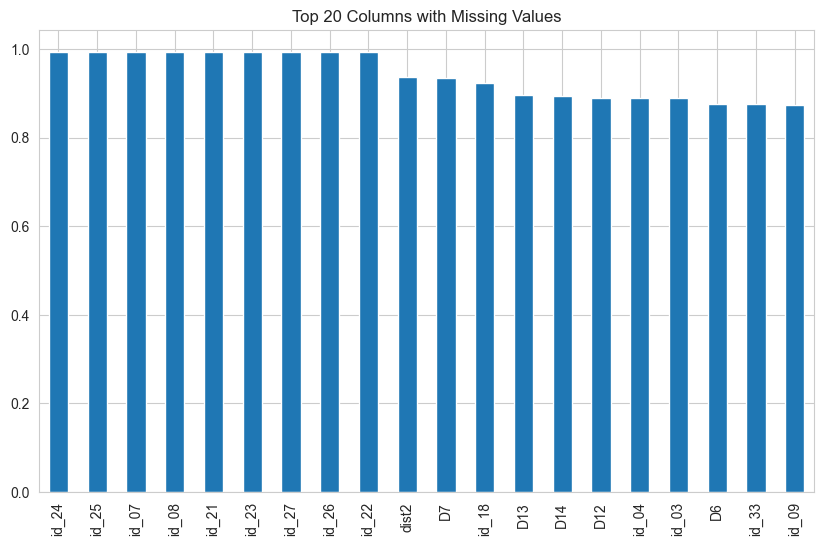

In [9]:
plt.figure(figsize=(10,6))
missing.head(20).plot(kind="bar")

plt.title("Top 20 Columns with Missing Values")
plt.show()

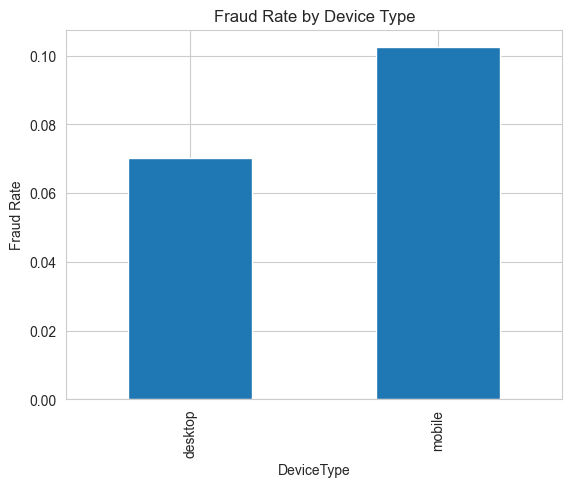

In [10]:
device_fraud = df.groupby("DeviceType")["isFraud"].mean()

device_fraud.plot(kind="bar")

plt.title("Fraud Rate by Device Type")
plt.ylabel("Fraud Rate")
plt.show()

In [11]:
email_fraud = df.groupby("P_emaildomain")["isFraud"].mean().sort_values(ascending=False)

email_fraud.head(10)

P_emaildomain
mail.com           0.345455
live.com.mx        0.135593
frontiernet.net    0.133333
outlook.es         0.088235
outlook.com        0.079365
gmail              0.066667
hotmail.com        0.055046
embarqmail.com     0.052632
hotmail.es         0.047619
gmail.com          0.044287
Name: isFraud, dtype: float64

## Key Observations from Exploratory Data Analysis

1. **Class Imbalance**
   Fraudulent transactions represent a very small percentage of total transactions (~3–4%). This means the dataset is highly imbalanced and special care must be taken during model training.

2. **Transaction Amount Patterns**
   Fraudulent transactions tend to cluster around specific transaction amounts, which may indicate automated fraud attempts or common purchase targets.

3. **Device Patterns**
   Certain device types appear more frequently in fraudulent transactions, suggesting that fraudsters may reuse the same devices.

4. **Email Domain Patterns**
   Some email domains show a higher fraud rate than others. These relationships can help connect transactions when building the transaction graph.